![Daniel Mwaka Phase 1 Project](images/dehavilland-dhc-hc-8-311.png)

# Data-Driven Decision Support for Aircraft Procument


<strong>Student:</strong> Daniel Mwaka

<strong> Student Pace:</strong> DSF-FT12-Hybrid

<strong> Instructor:</strong> Samuel Karu    


## Overview
This project aims to support the company's data-driven decision to procure relatively low-risk airplane models to operate the fleet in the commercial and private enterprise sectors. It analyzes a dataset compiled by the National Transportation Safety board and retrieved from Kaggle.com. Presented recommendations are deduced from descriptive statistics results and backed-up by interactive visualizations modeled using Tableau Public. 

## Business Problem
Venturing into a new industry avails a company of potential growth opportunities. Diversifying a company's portfolio lowers reliance on a single revenue stream (asset diversification) and optimizes resilience against unfavorable business environments/ factors (Luo, 2022). However, venturing into a highly sensitive sector, such as operating airplanes for commercial and private enterprises, necessitates data-driven decisions, strategic implementation, and formative performance evaluation (Altundag & Wynn, 2024). Purchasing airplane models prone to crashing poses a substantial risk to human life, brand image, competitiveness, profitability, and the company's longevity once it ventures into the new industry.  



## Data Understanding
The NTSB aviation accident database contains information on crashes and contingency incidents within the U.S., its territories, and across international waters from 1962 to 2023. The dataset was retrieved from Kaggle.com (NTSB, 2023). The dataset is formatted as a .csv file with 31 columns and 88889 rows. The columns are meticulously organized to capture variables of interest in aircraft accidents and incidents. Extracting, analyzing, and visualizing relevant data from the dataset is vital to shedding insight into the safest, low-risk airplane models for a new entrant to the commercial aviation industry.

However, the dataset is enormous, contains some missing values duplicates, and needs to be customized to meet new entrants' needs aiming to purchase and operate airplanes for commercial and private enterprises. For instance, it contains data for airplane crashes across multiple scenarios (purpose of the flight), in which some cases exceed the target scope of the company. For this project, the target variables are categorized into Dimensions and Measures. The Dimension variables include: Event Date, Investigation Type, Aircraft Damage, Location, Make, Model, Weather Condition, and Purpose of Flight. The Measure variables include: The number of Engines, Total Fatal Injuries, Total Minor Injuries, and Total Uninjured passengers. The insights yielded from analyzing these variables and visualizing their respective relationships are deemed appropriate for deducing recommendations to support data-driven decisions by the company to procure a fleet that comprises safe, low-risk airplanes   


## Data Preparation
Digital maturity in leveraging novel data analytics is the key driver for aircraft safety. Manufacturers use these technologies to design safer aircraft (Boyd & Stolzer, 2016). On the other hand, companies operating in the airline sector base their strategic procurement plans on data-supported decisions (Altundag & Wynn, 2024). The progressive scope in which key stakeholders in the airline sector are embracing data analytics is reflected in the cumulative number of aircraft accidents and accidents recorded by the NTSB for each decade. Additionally, structural and material design advancements progressively increase aircraft safety.



As captured in the time-series plot, the number of aircraft accidents and incidents has been dropping. The selected period is deemed appropriate because analyzing data for aircraft accidents and incidents before 2000 would comprise the reliability of deduced recommendations for real-world application in the 2020s.The next step is to drop all the columns deemed inappropriate for this project

## Data Modeling

DataFrame shape: (88889, 31)
DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50249 non-null  object 
 9   Airport.Name            52790 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87572 non-null  object

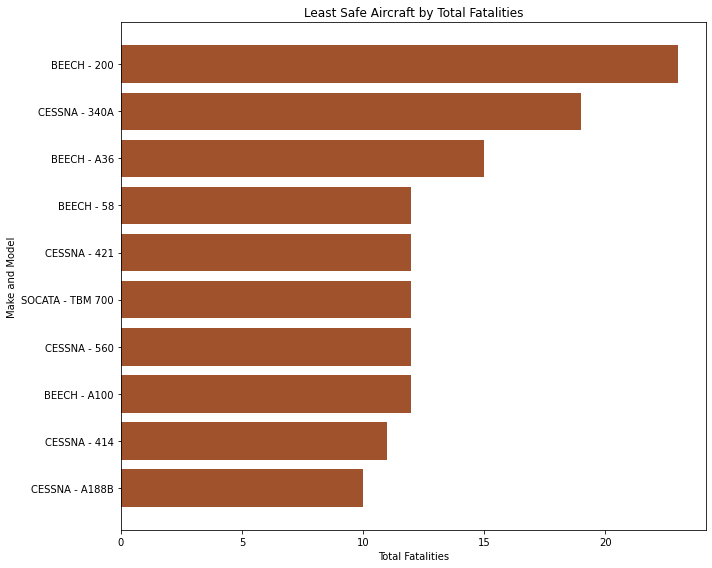

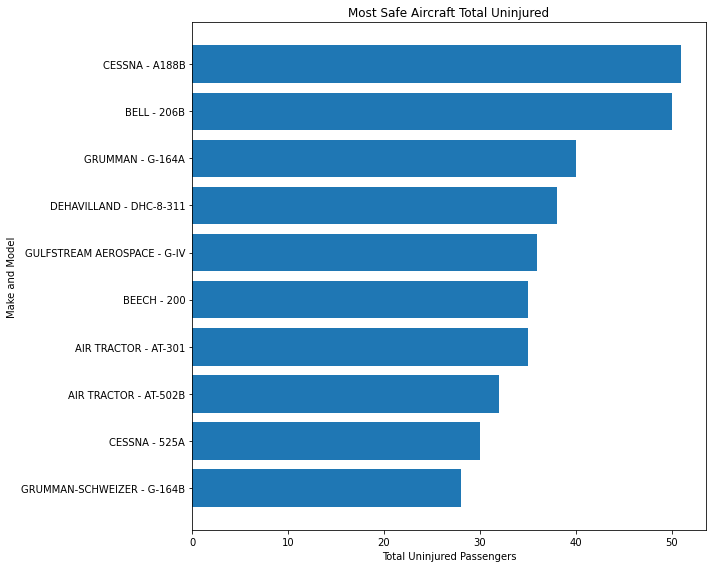

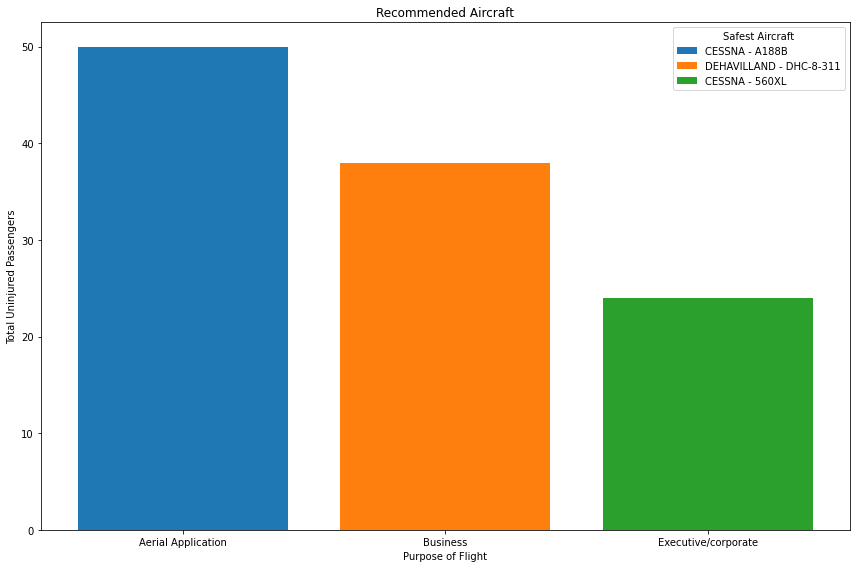

Plotting for multi-engine aircrafts...


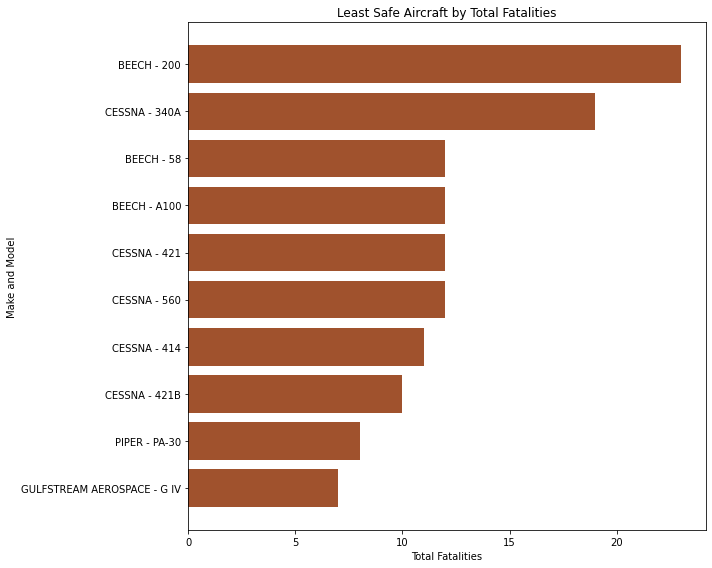

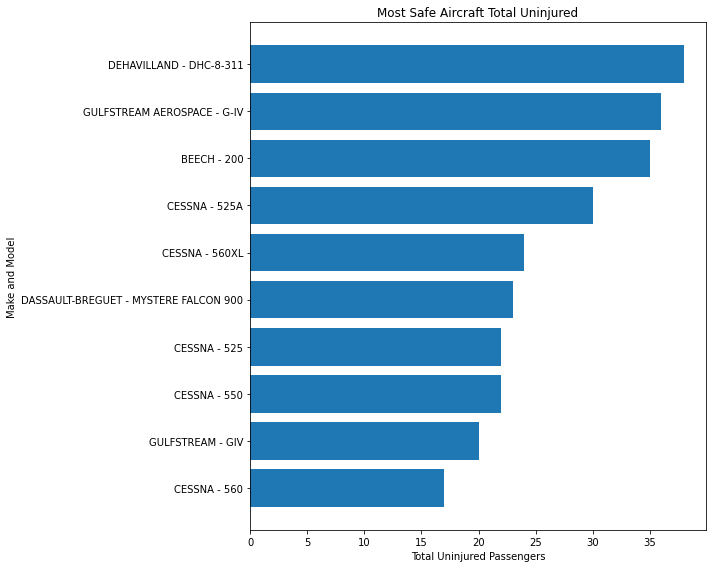

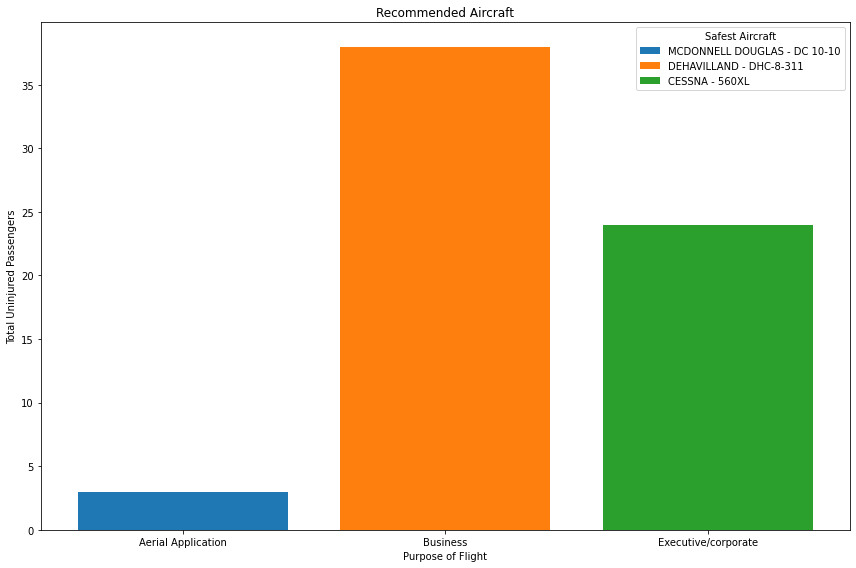

Plots generated successfully!


In [ ]:
import pandas as pd
from src.data_loader import load_data, initial_inspection
from src.data_cleaning import clean_data
from src.data_analysis import plot_safest_aircraft, plot_riskiest_aircraft, plot_recommended_aircraft

# Load and inspect data
df_master = load_data("data/aviation-data.csv")
df = initial_inspection(df_master)

# Clean the data
df = clean_data(df)
df.to_csv("data/cleaned-aviation-data.csv", index=False, encoding='latin1')
df_clean = pd.read_csv("data/cleaned-aviation-data.csv",encoding='latin1', low_memory=False)

# Analyze and plot data for all aircrafts
print("Plotting for all aircrafts...")
plot_riskiest_aircraft(df_clean)
plot_safest_aircraft(df_clean)
plot_recommended_aircraft(df_clean)

# Analyze and plot data for multi-engine aircrafts
print("Plotting for multi-engine aircrafts...")
df_modified = df_clean.copy()
df_modified = df_modified[df_modified['Number.of.Engines'].apply(lambda x: x >= 2)]
plot_riskiest_aircraft(df_modified, multi_engine=True)
plot_safest_aircraft(df_modified, multi_engine=True)
plot_recommended_aircraft(df_modified, multi_engine=True)

print("Plots generated successfully!")

## Evaluation
The baseline model shed the following insights:
* The BEECH-200 (8-seater), the CESSNA-340A (6-seater), and the BEECH-A36 (6-seater), are the top-three most risky aircraft overall.
* The CESSNA-A188B (1-seater), the BELL-206B (5-seater), and the GRUMMAN-G-164A (1-seater) are the top-three safest aircraft models overall.

<strong>Recommendations:</strong>

* The CESSNA-560XL (10-seater) is the safest aircraft for Executive/corporate flights.
* The DEHAVILLAND-DHC-8-311 (50-seater) is the safest airplane for business flights.
* The CESSNA-A188B (1-seater) is the safest aircraft for Aerial Applications.

The number of engines for these aircraft models. 
* BEECH-200: 2 engines   
* CESSNA-340A:2 engines
* BEECH-A36:1 engine
* BELL-206B: 1 engine
* GRUMMAN-G-164A: 1 engine
* CESSNA-560XL: 2 engines   
* CESSNA-A188B: 1 engine   
* DEHAVILLAND-DHC-8-311: 2 engines   

Multi-engine aircraft are typically safer in comparison to single-engine airplanes (Pilot Institute, 2023). More than one engine avails redundancy to propulsion units. Pilots can recalibrate controls and continue flying if one engine stalls or malfunctions. In contrast, such an incident in a single-engine aircraft poses a substantial risk of crashing if the gliding distance falls short of a runway or a relatively flat surface for an emergency landing. Thus, I modified the baseline model to drop row entries whose `Number.of.Engines` is less than 2.

The modified model sheds the following insight:
* The BEECH-200 (13-seater), the CESSNA-340A (6-seater), and the BEECH-A400 (8-seater) are the top-three most risky multi-engine aircraft to operate.
* The DEHAVILLAND DHC-8-311 (50-seater), the GULFSTREAM AEROSPACE-G-IV (10-seater), and the BEECH-200 (13-seater) are the top-three safest multi-engine aircraft to operate.


<strong>Recommendations:</strong>

* The CESSNA 560XL(10-seater) is the safest multi-engine aircraft for Executive/corporate flights.
* The DEHAVILLAND -DHC-8-311(50-seater) is the safest multi-engine aircraft for business flights.
* The MCDONNELL DOUGLAS-DC 10-10(250-seater) is the safest multi-engine aircraft for Aerial Applications.

The number of engines for these aircraft models. 
* BEECH-200: 2 engines   
* CESSNA-340A: 2 engines   
* BEECH-A400: 2 engines
* GULFSTREAM AEROSPACE-G-IV: 2 engines
* CESSNA 560XL: 2 engines   
* DEHAVILLAND DHC-8-311: 2 engines
* MCDONNELL DOUGLAS -DC 10-10: 3 engines

The findings from the results yielded by the baseline model are compared to those yielded by the modified model. After entering the industry, the recommended safest aircraft model for the aviation services the company will offer is based on respective applicability and operational logistics. 

## Conclusions
The analysis yields three recommendations on the aircraft models the company should procure and operate after entering the commercial aviation industry.
* <strong>The CESSNA-560XL aircraft is recommended for Executive/ Corporate flights:</strong> The baseline and modified model conform the aircraft is safest for executive and corporate flights.   
* <strong>The DEHAVILLAND DHC-8-311 aircraft is recommended for Business Flights:</strong> The baseline and modified model conform the aircraft is safest for business flights. 
* <strong>The CESSNA-A188B aircraft is recommended for Aerial Applications:</strong> The modified model proposes the MCDONNELL DOUGLAS-DC 10-10 (a three-engine, 250-seater) aircraft for aerial applications. The proposed alternative by the modified model is rejected because aerial applications typically include agricultural activities such as spraying crop fields. Hence, the single-engine CESSNA-A188B is recommended for aerial applications.

## References
Altundag, A., & Wynn, M. (2024). Advanced Analytics and Data Management in the Procurement Function: An Aviation Industry Case Study. Electronics, 13(8), 1554. https://doi.org/10.3390/electronics13081554

Boyd, D. D., & Stolzer, A. (2016). Accident-precipitating factors for crashes in turbine-powered general aviation aircraft. Accident Analysis & Prevention, 86, 209-216. https://doi.org/10.1016/j.aap.2015.10.024

NTSB. (2023). Aviation Accident Database & Synopses, up to 2023. https://doi.org/10.34740/KAGGLE/DSV/4875576

Luo, J. (2022). Data-driven innovation: What is it?. IEEE Transactions on Engineering Management, 70(2), 784-790. https://doi.org/10.1109/TEM.2022.3145231

Pilot Institute. (2023). Single Engine Vs. Multi Engine: Which is Better? https://pilotinstitute.com/single-vs-multi-engine/
